# Full calibration and comparison
- 14548R-neu and 150017L-fle

---

- effect of wait time before calibration frame
- effect of calibration F range
- effect of wait time before test frame
- effect of calibration fit type (try 3rd / 4th order polynomials)
- effect of translation to match instron offset
- effect of sensor loc

---

Ask about instron alignment

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import pyvista as pv
import matplotlib.pyplot as plt
from itertools import product
from tqdm import tqdm

from phd_helpers.paths import get_info_df

from helpers import (
    compute_power_law_coeffs, compute_img_metrics, compute_fe_grid_data, build_fe_data, fe_mets_from_mesh,
    F_from_path, avg_frames_from_paths, plot_comparison, plot_sensor_grids, compute_CA_overlap, save_errors,
    compute_error, compute_cop_error, compute_test_fe_error, apply_fit, compute_polynomial_coeffs, paired_parameter_sensitivity,
)

from errors import Errors

In [3]:
#•••••••••••••••• PATHS ••••••••••••••••#

# inputs for 20260904 experimental paths (not fe path)
sub = '14548R' 
pose = 'neu'
info_df = get_info_df('CMC')
tpm_vol = info_df['tpm_volume'][(info_df['subject'].astype(str)+info_df['side'] == sub)].values[0]



exp_path = Path('../../../../Experimental/LabData/contactTesting/20260904')

# calibration on high-1
cal_1_paths = list(exp_path.glob('calibration/cal_1*.asm'))
redos = [500, 700, 900]
redo_names = [f'cal_1_{x}N.asm' for x in redos]
cal_1_paths = [x for x in cal_1_paths if x.name not in redo_names]
cal_1_Fs = [F_from_path(x) for x in cal_1_paths]

# testing on high-1
test_1_paths = list(exp_path.glob(f'testing/{sub}/{pose}_1*.asm'))
test_1_Fs = [F_from_path(x) for x in test_1_paths]

# FE input
fea_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy')
inp_file = list(fea_path.glob('study3_35T*/**/*.inp'))[0]

offset_fea_path = Path('../../../../Computational/InpPipeline/outputs/initialFEAstuff/accuracy/TwistTranslate/ty-05to10/')
#•••••••••••••••• PATHS ••••••••••••••••#

In [4]:
#•••••••••••••••• PARAMETERS ••••••••••••••••#

# Calibration & Testing
sensor_id = 3
raw_mask = 0     # <= mask of raw sensor values
custom_masks = [[4, -1, 0]] # [[raw_mask_value, j_idx, k_idx], ...]
hold_time = 180 # instron hold time
avg_window = 5 # time window to average frames over

# FE
guide_wall_z = 10
sensor_offset = -2
bone = 'tpm'

# Calibration
#cal_start_time = 55 # start time of average window relative to detected hold start
#cal_F_range = (min(cal_1_Fs), max(cal_1_Fs))

# Testing
#test_start_time = 55 # start time of average window relative to detected hold start

#•••••••••••••••• PARAMETERS ••••••••••••••••#

#•••••••••••••••• LOOP PARAMETERS ••••••••••••••••#

start_times = [30, 60, 90] # for both calibration and testing

cal_start_times = start_times
cal_F_ranges = [(20, 800), (120, 500), (120, 800)] # (min, max) calibration frame forces for curve fit
test_start_times = start_times
fit_types = [
        #('power_law', True, '', True),
        ('power_law', False, '', True),

        #('poly', True, 3, True),
        #('poly', False, 3, False),
        #('poly', True, 3, False),
        ('poly', False, 3, True),

        #('poly', True, 4, True),
        #('poly', False, 4, False),
        #('poly', True, 4, False),
        ('poly', False, 4, True), # don't really have enough points for a 4th order 60 to 300 fit
    ] # type, weight_by_patch_size, poly_degree, poly, zero_intercept
#raw_masks = [0, 3, 5]
offsets = [0.0]#, 0.5, 0.75, 1.0]

#•••••••••••••••• LOOP PARAMETERS ••••••••••••••••#

cols = ['cal_wait', 'cal_F_range', 'test_wait', 'fit_type', 'offset']
cal_start_names = ['cal_wait_'+str(x) for x in cal_start_times]
cal_F_range_names = [f'cal_Fs_{x1}to{x2}' for x1, x2 in cal_F_ranges]
test_start_names = ['test_wait_'+str(x) for x in test_start_times]
fit_params_13 = ['-W', 'I0']
fit_names = [f'{fit_type}{(fit_params_13[0] if weight else '')}-{str(degree)}{(fit_params_13[1] if intrcpt else '')}' for fit_type, weight, degree, intrcpt in fit_types]
offset_names = ['offset_'+str(offset) for offset in offsets]
#raw_names = [f'raw_mask_{rm}' for rm in raw_masks]

combos = list(product(cal_start_times, cal_F_ranges, test_start_times, fit_types, offsets))
combos_names = list(product(cal_start_names, cal_F_range_names, test_start_names, fit_names, offset_names))


In [5]:
# precompute fe data cos that is not changing rn and takes time to compute
fe_data = build_fe_data(inp_file)
common_Fs = set(fe_data) & set(test_1_Fs)

fe_dict = {
    0.0: {
        'fe_data': fe_data,
        'common_Fs': common_Fs
    }
}

In [ ]:

for i, offset in enumerate(offsets[1:]):
    offset_inp_file = list(offset_fea_path.glob(f'**/{sub}/**/*-0{i}.inp'))[0]
    offset_csv_dir = list(offset_fea_path.glob(f'aire/output/firstRun/resultCSVs/{sub}-*-0{i}'))[0]
    offset_fe_data = build_fe_data(offset_inp_file, offset_csv_dir)
    fe_dict[offset] = {
        'fe_data': offset_fe_data,
        'common_Fs': set(offset_fe_data) & set(test_1_Fs)
    }

In [6]:
run_id = '6-comp'
errors = []
for cal_start_time, cal_F_range, test_start_time, fit_type, offset in tqdm(combos):
    errors.append(Errors(
            fe_data=fe_dict[offset]['fe_data'], 
            common_Fs=fe_dict[offset]['common_Fs'], 
            cal_F_range=cal_F_range,
            cal_1_Fs=cal_1_Fs,
            cal_1_paths=cal_1_paths,
            test_1_Fs=test_1_Fs,
            test_1_paths=test_1_paths,
            sensor_id=sensor_id, 
            raw_mask=raw_mask, 
            custom_masks=custom_masks, 
            hold_time=hold_time, 
            avg_window=avg_window, 
            cal_start_time=cal_start_time, 
            test_start_time=test_start_time, 
            guide_wall_z=guide_wall_z, 
            sensor_offset=sensor_offset, 
            bone=bone,
            bone_vol=tpm_vol,
            fit_type=fit_type,
            print_raw_warning=False
        ).errors)

save_errors(combos, cols, errors, run_id=run_id)

100%|██████████| 81/81 [04:19<00:00,  3.21s/it]


### Focus on mape (mean absolute % error) for now
- Non-zero intercept is bad
- Weighting makes negligable difference 
- Raw mask is bad

In [7]:
error_metric = 'mape'
mape_cols_instron = {target_error+'-'+error_metric: [combo[target_error][error_metric] for combo in errors] for target_error in ['cal_error', 'test_error']}
mape_cols_fe = {f'fe_grid_{metric}-{error_metric}': [combo['fe_grid_error'][metric][error_metric] for combo in errors] for metric in errors[0]['fe_grid_error']}
combo_cols = {col: np.asarray(combos_names)[:, i] for i, col in enumerate(cols)}

df = pd.DataFrame(combo_cols | mape_cols_instron | mape_cols_fe)
#I0_mask = [x[-2:] == 'I0' for x in df['fit_type']]
#df = df[I0_mask]
error_cols = [x for x in df.columns if x not in cols]
#error_cols = ['cal_error-mape', 'test_error-mape']
df[f'{error_metric}_sum'] = df[error_cols].sum(axis=1)
df['CAO_mean_pct'] = pd.DataFrame(errors)['CAO_mean_pct']
df.sort_values(f'{error_metric}_sum')

,cal_wait,cal_F_range,test_wait,fit_type,offset,cal_error-mape,test_error-mape,fe_grid_P_max-mape,fe_grid_P_avg-mape,fe_grid_CA-mape,mape_sum,CAO_mean_pct
71,cal_wait_90,cal_Fs_120to500,test_wait_90,poly-4I0,offset_0.0,0.214559,10.899626,45.545810,15.296563,19.992324,91.948882,80.376154
80,cal_wait_90,cal_Fs_120to800,test_wait_90,poly-4I0,offset_0.0,0.517966,13.270123,46.283873,12.653338,19.992324,92.717624,80.376154
70,cal_wait_90,cal_Fs_120to500,test_wait_90,poly-3I0,offset_0.0,0.285390,9.224109,45.029483,18.209248,19.992324,92.740554,80.376154
69,cal_wait_90,cal_Fs_120to500,test_wait_90,power_law-I0,offset_0.0,0.365795,10.169864,45.624863,16.668723,19.992324,92.821569,80.376154
44,cal_wait_60,cal_Fs_120to500,test_wait_90,poly-4I0,offset_0.0,0.219353,10.996825,46.083390,15.976726,19.992324,93.268618,80.376154
...,...,...,...,...,...,...,...,...,...,...,...,...
25,cal_wait_30,cal_Fs_120to800,test_wait_90,poly-3I0,offset_0.0,1.204940,7.109108,47.767100,25.615303,19.992324,101.688774,80.376154
7,cal_wait_30,cal_Fs_20to800,test_wait_90,poly-3I0,offset_0.0,2.199352,7.971260,47.668361,23.984357,19.992324,101.815654,80.376154
3,cal_wait_30,cal_Fs_20to800,test_wait_60,power_law-I0,offset_0.0,4.276832,12.370731,47.902594,17.749333,20.038364,102.337853,80.304027
22,cal_wait_30,cal_Fs_120to800,test_wait_60,poly-3I0,offset_0.0,1.204940,6.940724,47.873937,26.467970,20.038364,102.525936,80.304027


In [8]:
df[error_cols+['CAO_mean_pct']].describe().loc[['mean', 'min', 'max']]

,cal_error-mape,test_error-mape,fe_grid_P_max-mape,fe_grid_P_avg-mape,fe_grid_CA-mape,CAO_mean_pct
mean,1.301309,10.591950,46.649316,18.437767,19.929495,80.104961
min,0.214559,6.327584,44.859735,12.458775,19.757798,79.634700
max,4.276832,15.292391,47.902594,26.467970,20.038364,80.376154


In [9]:
paired_parameter_sensitivity(df, cols, 'mape_sum').sort_values('max_change')

,parameter,level_1,level_2,n_pairs,max_change,mean_change,min_change
3,cal_F_range,cal_Fs_20to800,cal_Fs_120to500,27,-3.213498,-4.697302,-5.644609
1,cal_wait,cal_wait_30,cal_wait_90,27,-1.289382,-3.141739,-4.069002
0,cal_wait,cal_wait_30,cal_wait_60,27,-0.733569,-2.079011,-2.655770
10,fit_type,power_law-I0,poly-4I0,27,-0.534791,-1.378612,-2.097222
2,cal_wait,cal_wait_60,cal_wait_90,27,-0.459646,-1.062729,-1.435831
11,fit_type,poly-3I0,poly-4I0,27,-0.238251,-2.602285,-6.191923
8,test_wait,test_wait_60,test_wait_90,27,-0.234034,-0.993504,-1.413010
4,cal_F_range,cal_Fs_20to800,cal_Fs_120to800,27,-0.027953,-2.433080,-4.287415
7,test_wait,test_wait_30,test_wait_90,27,0.379453,-0.486054,-1.612571
6,test_wait,test_wait_30,test_wait_60,27,1.216614,0.507449,-0.619082


In [10]:
paired_parameter_sensitivity(df, cols, 'fe_grid_P_max-mape').sort_values('max_change')

,parameter,level_1,level_2,n_pairs,max_change,mean_change,min_change
1,cal_wait,cal_wait_30,cal_wait_90,27,-1.241142,-1.324715,-1.535905
0,cal_wait,cal_wait_30,cal_wait_60,27,-0.724624,-0.837009,-0.998325
3,cal_F_range,cal_Fs_20to800,cal_Fs_120to500,27,-0.707134,-1.084357,-1.571480
2,cal_wait,cal_wait_60,cal_wait_90,27,-0.460557,-0.487706,-0.544539
8,test_wait,test_wait_60,test_wait_90,27,0.011257,-0.043437,-0.106837
4,cal_F_range,cal_Fs_20to800,cal_Fs_120to800,27,0.151197,-0.137416,-0.360123
10,fit_type,power_law-I0,poly-4I0,27,0.195437,-0.020804,-0.138882
6,test_wait,test_wait_30,test_wait_60,27,0.215114,0.160115,0.051826
7,test_wait,test_wait_30,test_wait_90,27,0.216377,0.116678,-0.055011
9,fit_type,power_law-I0,poly-3I0,27,0.405953,-0.156529,-0.657341


# Plot

In [15]:
# precompute fe data cos that is not changing rn and takes a long time to compute
fe_data = build_fe_data(inp_file)
common_Fs = set(fe_data) & set(test_1_Fs)

In [16]:
#•••••••••••••••• PARAMETERS ••••••••••••••••#

# Calibration & Testing
sensor_id = 3
raw_mask = 0     # <= mask of raw sensor values
custom_masks = [[4, -1, 0]] # [[raw_mask_value, j_idx, k_idx], ...]
hold_time = 180 # instron hold time
avg_window = 5 # time window to average frames over

# FE
guide_wall_z = 10
sensor_offset = -2
bone = 'tpm'

# Calibration
cal_start_time = 45 # start time of average window relative to detected hold start
cal_F_range = (20, 900)
fit_type = ('poly', False, 3, True)

# Testing
test_start_time = 45 # start time of average window relative to detected hold start

#•••••••••••••••• PARAMETERS ••••••••••••••••#

def_errors = Errors(
            fe_data=fe_data, 
            common_Fs=common_Fs, 
            cal_F_range=cal_F_range,
            cal_1_Fs=cal_1_Fs,
            cal_1_paths=cal_1_paths,
            test_1_Fs=test_1_Fs,
            test_1_paths=test_1_paths,
            sensor_id=sensor_id, 
            raw_mask=raw_mask, 
            custom_masks=custom_masks, 
            hold_time=hold_time, 
            avg_window=avg_window, 
            cal_start_time=cal_start_time, 
            test_start_time=test_start_time, 
            guide_wall_z=guide_wall_z, 
            sensor_offset=sensor_offset, 
            bone=bone,
            bone_vol=tpm_vol,
            fit_type=fit_type
        )

Fully saturated calibration sensel !


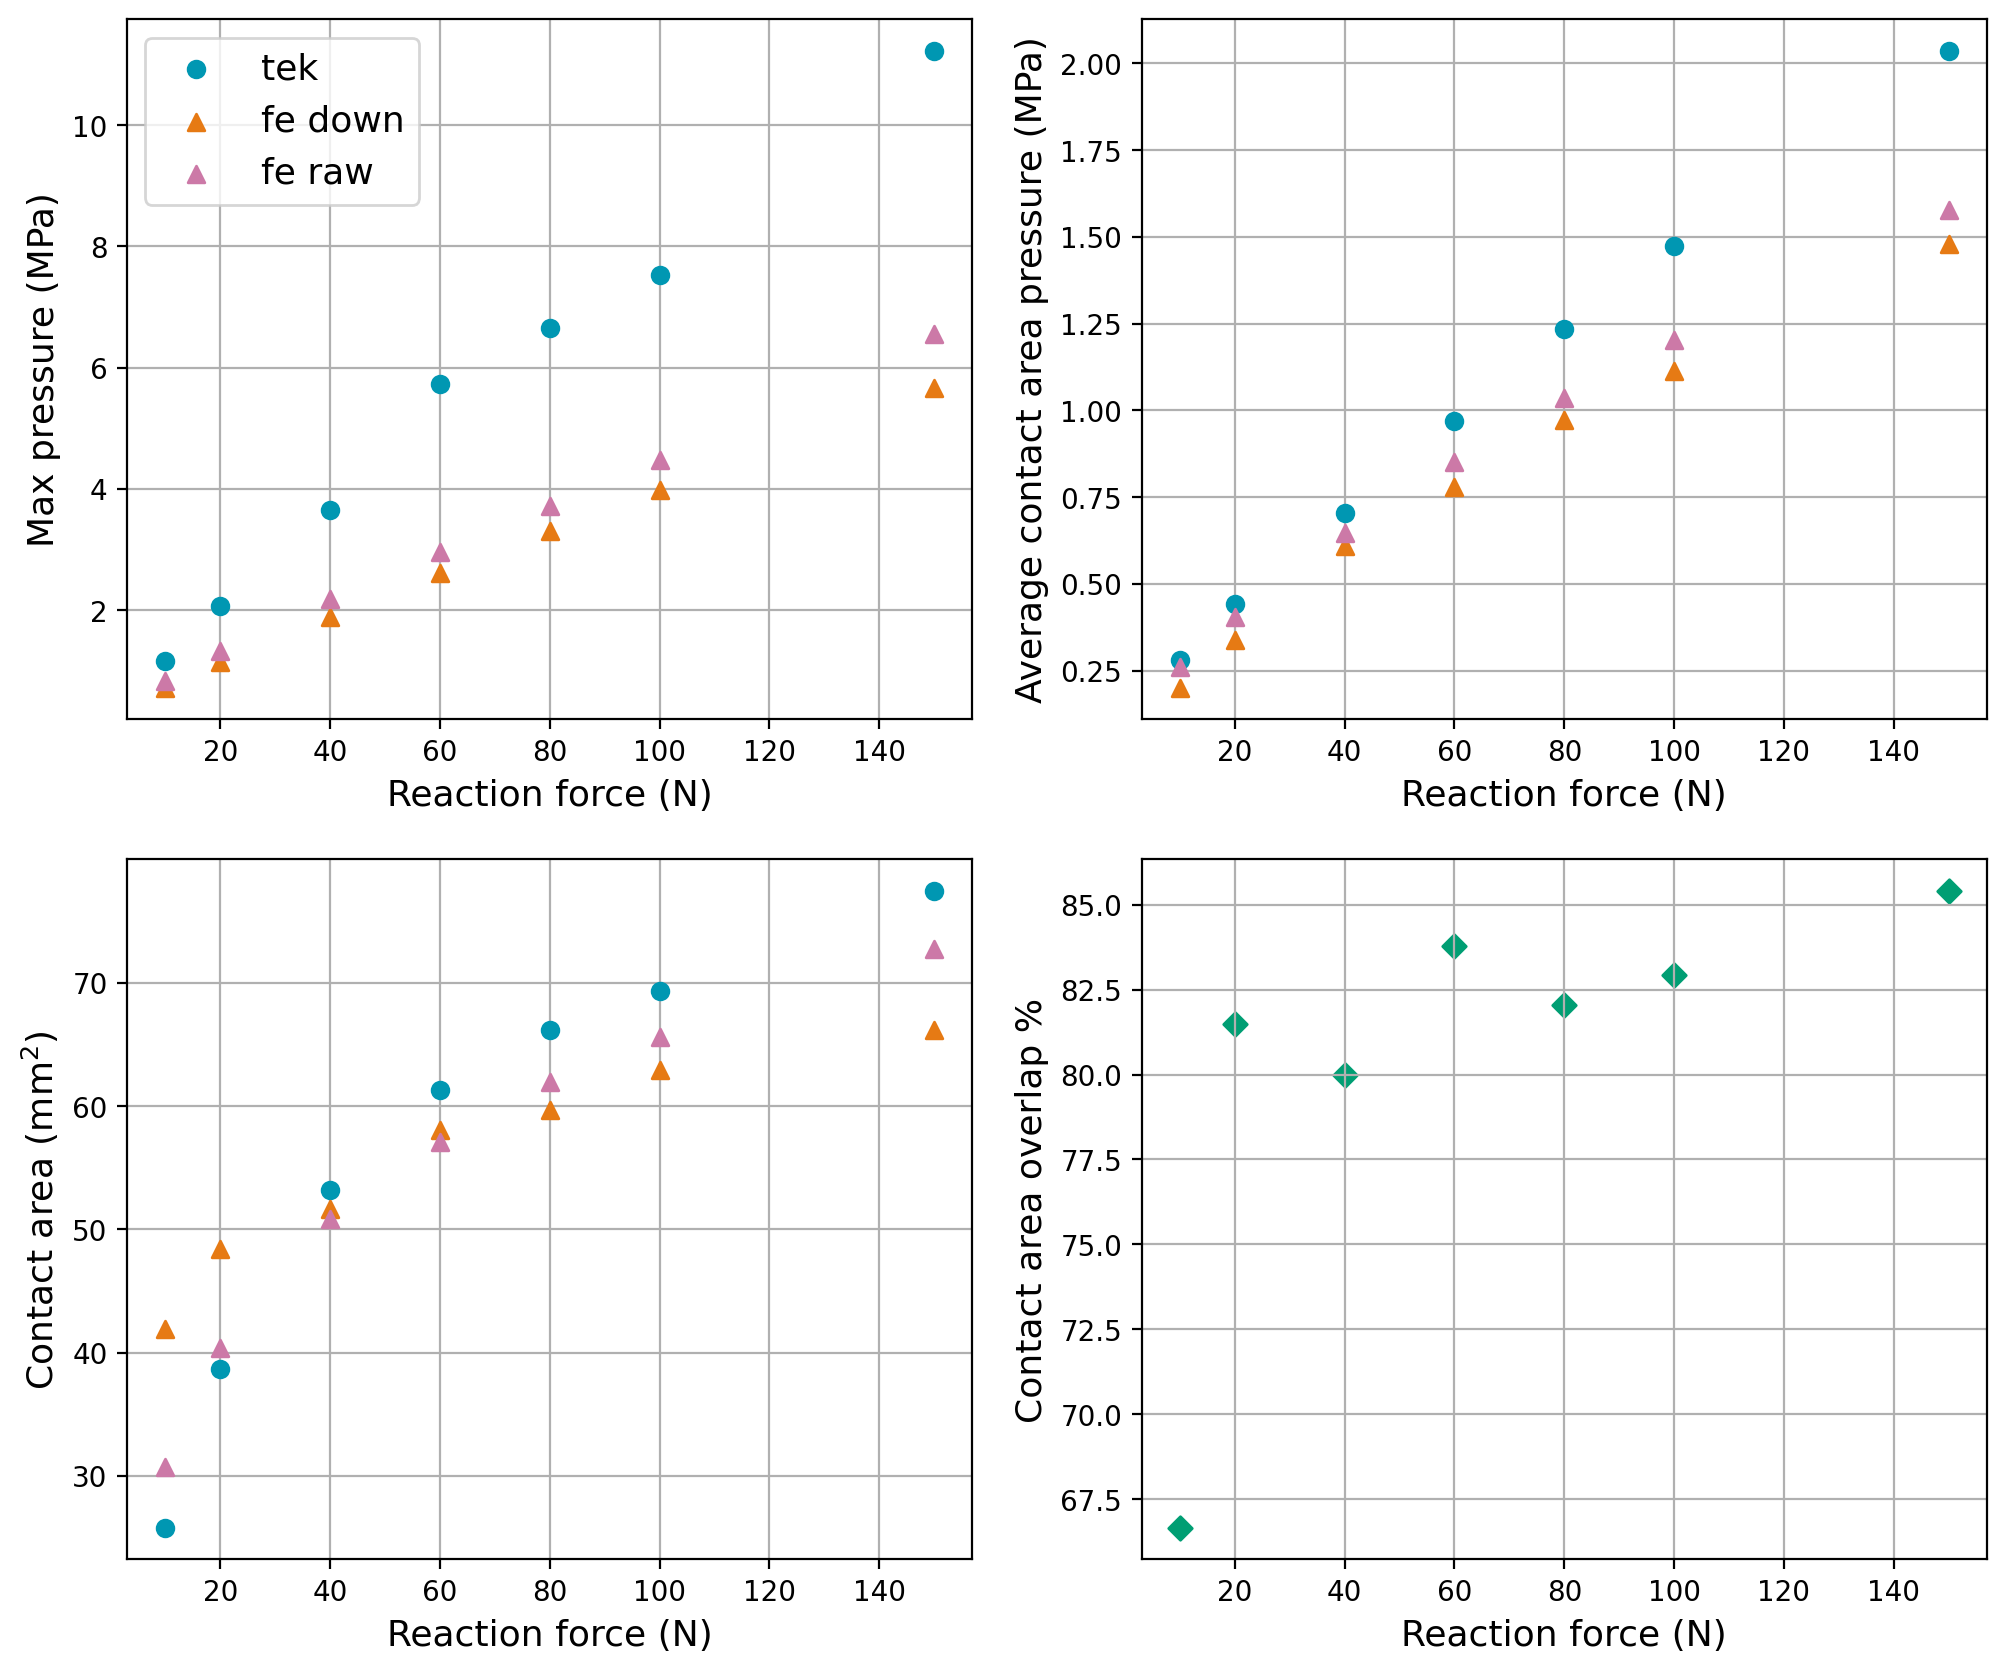

In [19]:
plot_comparison(
    def_errors.test_mets, def_errors.fe_grid_mets, def_errors.fe_mets, common_Fs, def_errors.fe_grid_data, def_errors.test_frames_mpa
    )

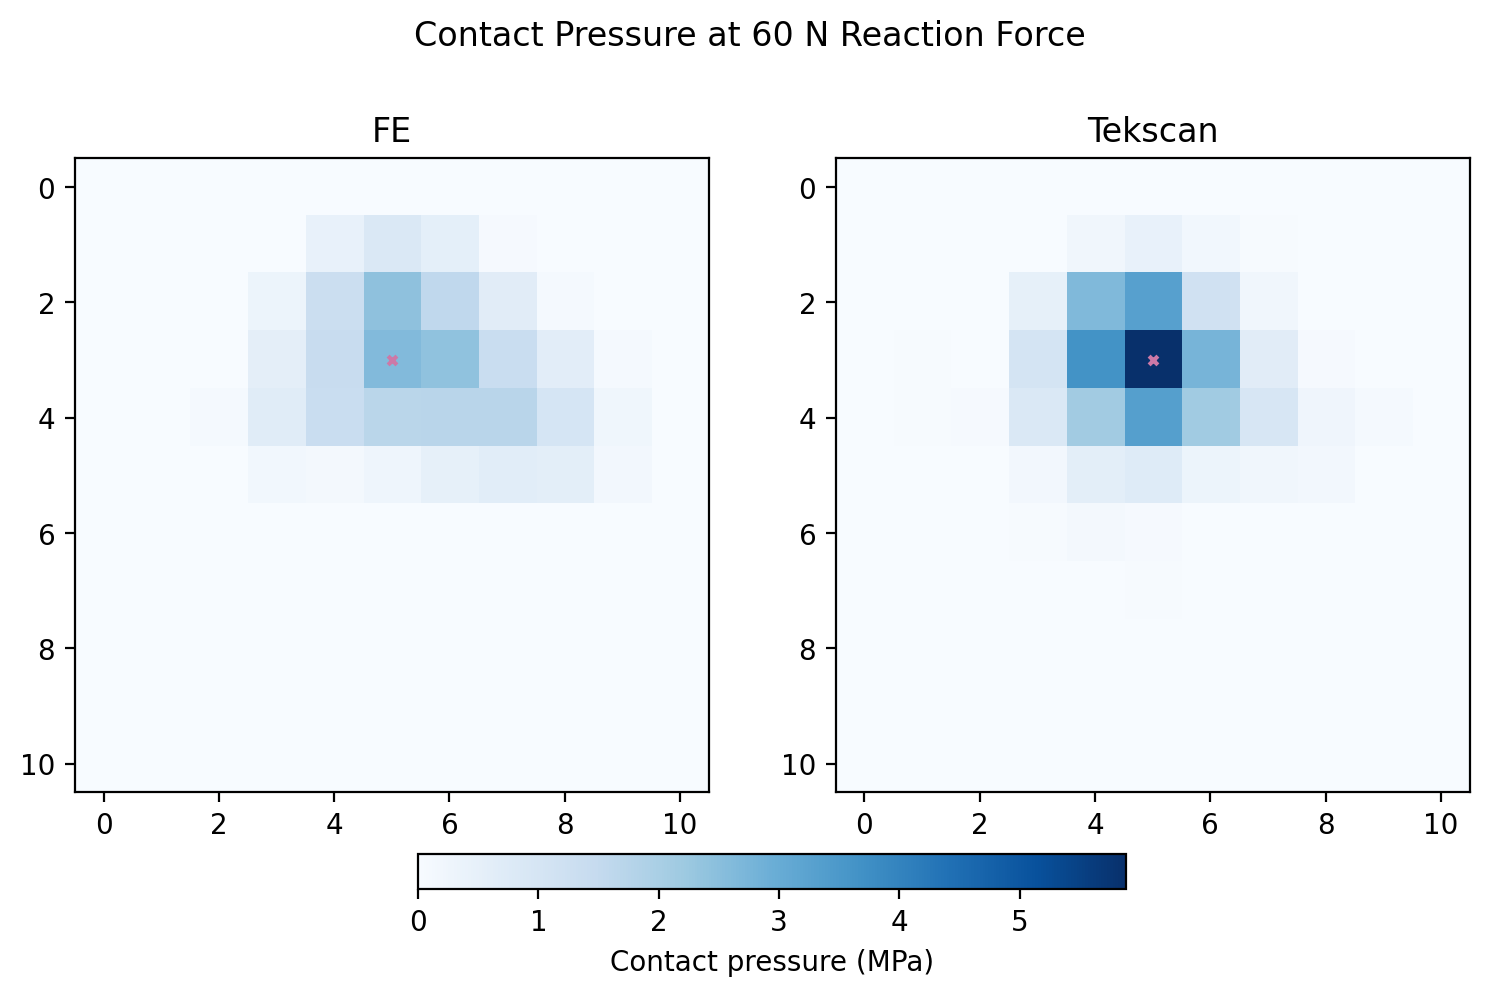

In [4]:
F = 60
plot_sensor_grids(F, fe_grid_data, test_frames_mpa)

In [22]:
def_errors.test_frames[100].max()

np.float64(166.46913580246914)

In [ ]:
np.argmax(def_errors.test_frames[100])
# same as on day in holdLength.ipynb 
# but on that day max raw at 100 N was 150 
# how come ???

np.int64(82)